In [1]:
import xarray as xr
import numpy as np
import glob
import cfgrib

base_path = "/Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/sealevel_from_dkss2020/"
all_files = sorted(f for f in glob.glob(base_path + "dkss_grib_sealev.*")
                   if not f.endswith('.idx'))
print(f"Totale file GRIB (senza .idx): {len(all_files)}")
print(f"Primo : {all_files[0].split('/')[-1]}")
print(f"Ultimo: {all_files[-1].split('/')[-1]}")

example = all_files[-1]
print(f"\nFile di esempio: {example.split('/')[-1]}")

# Apri tutti i messaggi GRIB nel file
messages = cfgrib.open_datasets(example)
print(f"\nNumero di sotto-dataset (messaggi GRIB diversi): {len(messages)}")

for i, ds in enumerate(messages):
    print(f"\n{'='*60}")
    print(f"SOTTO-DATASET {i}")
    print(f"{'='*60}")
    print(f"  Variabili  : {list(ds.data_vars)}")
    print(f"  Dimensioni : {dict(ds.sizes)}")
    print(f"  Coordinate : {list(ds.coords)}")

    # Dominio e risoluzione spaziale
    if 'latitude' in ds.coords and 'longitude' in ds.coords:
        lats = ds.latitude.values.flatten()
        lons = ds.longitude.values.flatten()
        print(f"\n  Dominio:")
        print(f"    Lat: {lats.min():.4f}° → {lats.max():.4f}°N")
        print(f"    Lon: {lons.min():.4f}° → {lons.max():.4f}°E")
        unique_lats = np.unique(lats)
        unique_lons = np.unique(lons)
        if len(unique_lats) > 1:
            dlat = np.median(np.diff(np.sort(unique_lats)))
            print(f"    Δlat ~ {dlat:.5f}° ≈ {dlat*111:.2f} km")
        if len(unique_lons) > 1:
            dlon = np.median(np.diff(np.sort(unique_lons)))
            print(f"    Δlon ~ {dlon:.5f}° ≈ {dlon*111*np.cos(np.radians(np.mean(lats))):.2f} km")
        print(f"    Punti griglia: {len(unique_lats)} lat × {len(unique_lons)} lon = {len(unique_lats)*len(unique_lons)}")

    # Tempo / step
    for tcoord in ['time', 'valid_time', 'step']:
        if tcoord in ds.coords:
            v = ds[tcoord].values
            if v.ndim == 0:
                print(f"  {tcoord}: {v}")
            else:
                print(f"  {tcoord}: {v[0]} → {v[-1]}  (N={len(v)})")

    # Variabili dati — statistiche
    for vname, var in ds.data_vars.items():
        vals = var.values
        valid = vals[np.isfinite(vals) & (vals < 1e29)]
        attrs = var.attrs
        print(f"\n  Variabile '{vname}':")
        print(f"    long_name     : {attrs.get('long_name', 'n/d')}")
        print(f"    units         : {attrs.get('units', 'n/d')}")
        print(f"    GRIB_name     : {attrs.get('GRIB_name', attrs.get('name', 'n/d'))}")
        print(f"    GRIB_shortName: {attrs.get('GRIB_shortName', attrs.get('shortName', 'n/d'))}")
        print(f"    shape         : {var.shape}  dims={var.dims}")
        if len(valid) > 0:
            print(f"    min={valid.min():.4f}  max={valid.max():.4f}  mean={valid.mean():.4f}  std={valid.std():.4f}")
        else:
            print(f"    ⚠ Nessun valore valido")
        # Tutti gli attributi GRIB
        grib_attrs = {k: v for k, v in attrs.items() if 'GRIB' in k or k in ('units','long_name','standard_name')}
        print(f"    Attributi chiave:")
        for k, v in grib_attrs.items():
            print(f"      {k}: {v}")


Totale file GRIB (senza .idx): 3944
Primo : dkss_grib_sealev.2021100112
Ultimo: dkss_grib_sealev.2024061700

File di esempio: dkss_grib_sealev.2024061700

Numero di sotto-dataset (messaggi GRIB diversi): 1

SOTTO-DATASET 0
  Variabili  : ['p82']
  Dimensioni : {'step': 6, 'latitude': 482, 'longitude': 396}
  Coordinate : ['time', 'step', 'surface', 'latitude', 'longitude', 'valid_time']

  Dominio:
    Lat: 53.5870° → 57.5960°N
    Lon: 9.3400° → 14.8260°E
    Δlat ~ 0.00800° ≈ 0.89 km
    Δlon ~ 0.01389° ≈ 0.87 km
    Punti griglia: 482 lat × 396 lon = 190872
  time: 2024-06-16T18:00:00.000000000
  valid_time: 2024-06-16T19:00:00.000000000 → 2024-06-17T00:00:00.000000000  (N=6)
  step: 3600000000000 nanoseconds → 21600000000000 nanoseconds  (N=6)

  Variabile 'p82':
    long_name     : Experimental product
    units         : ~
    GRIB_name     : Experimental product
    GRIB_shortName: ~
    shape         : (6, 482, 396)  dims=('step', 'latitude', 'longitude')
    min=-0.0282  max=0

In [3]:
import xarray as xr
import numpy as np
import glob

# ── Percorso corretto ai file GRIB DKSS ──
base_path = "/Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/sealevel_from_dkss2020/"
all_files = sorted(glob.glob(base_path + "dkss_grib_sealev.*"))
print(f"Totale file trovati: {len(all_files)}")
print(f"Primo file : {all_files[0]}")
print(f"Ultimo file: {all_files[-1]}")

# ── Apri un file d'esempio ──
example_file = all_files[-1]
print(f"\n{'='*70}")
print(f"FILE D'ESEMPIO: {example_file}")
print(f"{'='*70}")

ds = xr.open_dataset(example_file, engine='cfgrib')

# 1) Panoramica generale del dataset
print("\n" + "="*70)
print("PANORAMICA DEL DATASET (xr.Dataset)")
print("="*70)
print(ds)

# 2) Dimensioni
print("\n" + "="*70)
print("DIMENSIONI")
print("="*70)
for dim, size in ds.dims.items():
    print(f"  {dim}: {size}")

# 3) Coordinate
print("\n" + "="*70)
print("COORDINATE")
print("="*70)
for coord_name, coord in ds.coords.items():
    print(f"\n  ▶ {coord_name}")
    print(f"    dtype : {coord.dtype}")
    print(f"    shape : {coord.shape}")
    vals = coord.values
    if vals.ndim == 0:
        print(f"    valore: {vals}")
    elif vals.size <= 10:
        print(f"    valori: {vals}")
    else:
        print(f"    min   : {np.nanmin(vals)}")
        print(f"    max   : {np.nanmax(vals)}")
        print(f"    primi : {vals.flat[:5]}")
    if coord.attrs:
        for k, v in coord.attrs.items():
            print(f"    [{k}]: {v}")

# 4) Variabili dati
print("\n" + "="*70)
print("VARIABILI DATI (data_vars)")
print("="*70)
for var_name in ds.data_vars:
    var = ds[var_name]
    print(f"\n  ▶ {var_name}")
    print(f"    dimensioni: {var.dims}")
    print(f"    shape     : {var.shape}")
    print(f"    dtype     : {var.dtype}")
    vals = var.values
    valid = vals[np.isfinite(vals) & (vals < 1e30)]
    if len(valid) > 0:
        print(f"    min (valid): {valid.min():.6f}")
        print(f"    max (valid): {valid.max():.6f}")
        print(f"    mean(valid): {valid.mean():.6f}")
        print(f"    std (valid): {valid.std():.6f}")
        print(f"    N validi   : {len(valid)} / {vals.size}")
    else:
        print(f"    ⚠ Nessun valore valido trovato")
    # Attributi della variabile (qui si vede se ci sono info sulle forzanti)
    if var.attrs:
        print(f"    --- Attributi ---")
        for k, v in var.attrs.items():
            print(f"    [{k}]: {v}")

# 5) Attributi globali del dataset
print("\n" + "="*70)
print("ATTRIBUTI GLOBALI DEL DATASET")
print("="*70)
if ds.attrs:
    for k, v in ds.attrs.items():
        print(f"  [{k}]: {v}")
else:
    print("  (nessun attributo globale)")

# 6) Prova ad aprire con TUTTI i filtri cfgrib per vedere se ci sono più variabili nascoste
print("\n" + "="*70)
print("TENTATIVO: apertura con backend_kwargs diversi per scoprire altre variabili")
print("="*70)
try:
    datasets = xr.open_datasets(example_file, engine='cfgrib')
    if len(datasets) > 1:
        print(f"  Trovati {len(datasets)} sotto-dataset nel file!")
        for i, sub_ds in enumerate(datasets):
            print(f"\n  --- Sotto-dataset {i} ---")
            print(f"  Variabili: {list(sub_ds.data_vars)}")
            print(f"  Coordinate: {list(sub_ds.coords)}")
            print(sub_ds)
    else:
        print("  Un solo dataset trovato (nessuna variabile nascosta).")
except Exception as e:
    print(f"  xr.open_datasets non disponibile o errore: {e}")
    # Fallback: prova con filtri diversi
    try:
        ds2 = xr.open_dataset(example_file, engine='cfgrib',
                               backend_kwargs={'indexpath': ''})
        print(f"  Variabili trovate (indexpath=''): {list(ds2.data_vars)}")
    except Exception as e2:
        print(f"  Anche il fallback ha dato errore: {e2}")

print("\n" + "="*70)
print("RIEPILOGO")
print("="*70)
print(f"  File totali nel dataset: {len(all_files)}")
print(f"  Periodo: da {all_files[0].split('.')[-1]} a {all_files[-1].split('.')[-1]}")
print(f"  Variabili dati: {list(ds.data_vars)}")
print(f"  Coordinate: {list(ds.coords)}")
print(f"  Dimensioni: {dict(ds.dims)}")


Can't create file '/Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/sealevel_from_dkss2020/dkss_grib_sealev.2024061700.5b7b6.idx.5b7b6.idx'
Traceback (most recent call last):
  File "/Users/nicolocaron/miniconda3/lib/python3.13/site-packages/cfgrib/messages.py", line 274, in itervalues
    yield self.filestream.message_from_file(file, errors=errors)
          ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^
  File "/Users/nicolocaron/miniconda3/lib/python3.13/site-packages/cfgrib/messages.py", line 341, in message_from_file
    return Message.from_file(file, offset, **kwargs)
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/nicolocaron/miniconda3/lib/python3.13/site-packages/cfgrib/messages.py", line 105, in from_file
    raise EOFError("End of file: %r" % file)
EOFError: End of file: <_io.BufferedReader name='/Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/sealevel_from_dkss2020/dkss_grib_sealev.2024061700.5b7b6.idx'>

During handling of the above exception, anot

Totale file trovati: 7888
Primo file : /Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/sealevel_from_dkss2020/dkss_grib_sealev.2021100112
Ultimo file: /Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/sealevel_from_dkss2020/dkss_grib_sealev.2024061700.5b7b6.idx

FILE D'ESEMPIO: /Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/sealevel_from_dkss2020/dkss_grib_sealev.2024061700.5b7b6.idx


EOFError: No valid message found: '/Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/sealevel_from_dkss2020/dkss_grib_sealev.2024061700.5b7b6.idx'

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader
import xarray as xr
import glob

# Use the last file for a recent forecast (filter out .idx files)
latest_file = all_files[-1]
print(f"Latest file: {latest_file}")
ds = xr.open_dataset(latest_file, engine='cfgrib')

# Replace sentinel missing values with NaN
data = ds['p82'].where(ds['p82'] < 1e30)

# Symmetric colorbar around 0
vmax = float(np.nanmax(np.abs(data.values)))
vmin = -vmax

# Prepare admin-1 (regions/provinces) feature
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)

fig, axes = plt.subplots(2, 3, figsize=(18, 12),
                          subplot_kw={'projection': ccrs.Mercator()})

for idx, ax in enumerate(axes.flat):
    step_data = data.isel(step=idx)
    vt = str(ds.valid_time.values[idx])[:16]

    im = ax.pcolormesh(
        ds.longitude.values, ds.latitude.values,
        step_data.values,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r', vmin=vmin, vmax=vmax, shading='auto'
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.7, linestyle='-', edgecolor='black')
    ax.add_feature(states_provinces, linewidth=0.5, edgecolor='dimgray', linestyle='--')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
    ax.set_title(f"Valid: {vt}", fontsize=11, fontweight='bold')
    ax.set_extent([9.3, 14.9, 53.5, 57.7], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

run_time = str(ds.time.values)[:16]
fig.suptitle(f'Sea Level Height — DKSS Hydro Model Forecast\nRun: {run_time}',
             fontsize=15, fontweight='bold', y=1.01)

cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                     fraction=0.04, pad=0.06, aspect=40)
cbar.set_label('Sea Level Height (m)', fontsize=12)

plt.tight_layout()
plt.show()


Can't create file '/Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/sealevel_from_dkss2020/dkss_grib_sealev.2024061700.5b7b6.idx.5b7b6.idx'
Traceback (most recent call last):
  File "/Users/nicolocaron/miniconda3/lib/python3.13/site-packages/cfgrib/messages.py", line 274, in itervalues
    yield self.filestream.message_from_file(file, errors=errors)
          ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^
  File "/Users/nicolocaron/miniconda3/lib/python3.13/site-packages/cfgrib/messages.py", line 341, in message_from_file
    return Message.from_file(file, offset, **kwargs)
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/nicolocaron/miniconda3/lib/python3.13/site-packages/cfgrib/messages.py", line 105, in from_file
    raise EOFError("End of file: %r" % file)
EOFError: End of file: <_io.BufferedReader name='/Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/sealevel_from_dkss2020/dkss_grib_sealev.2024061700.5b7b6.idx'>

During handling of the above exception, anot

Latest file: /Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/sealevel_from_dkss2020/dkss_grib_sealev.2024061700.5b7b6.idx


EOFError: No valid message found: '/Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/sealevel_from_dkss2020/dkss_grib_sealev.2024061700.5b7b6.idx'

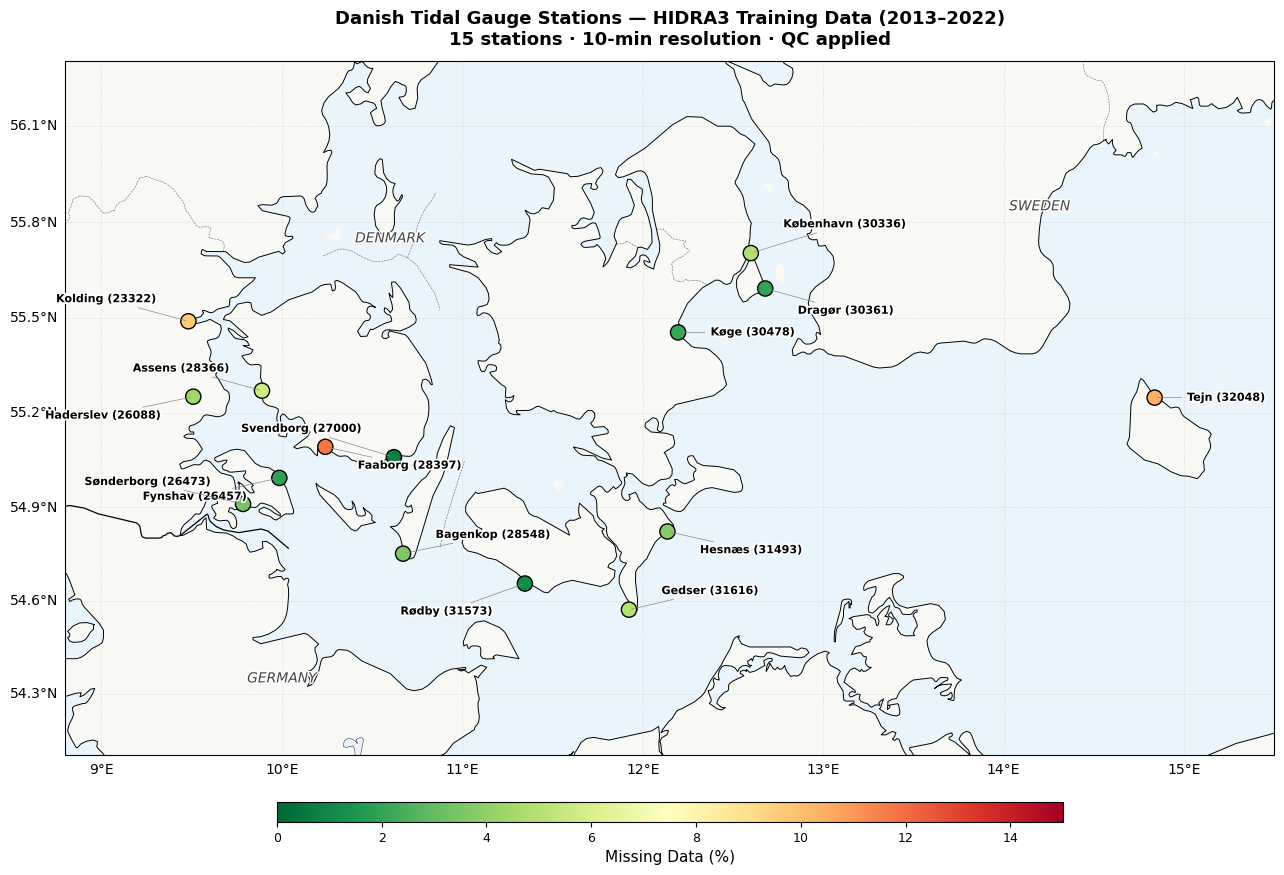

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
})

# ── Dati stazioni (2013-2022) ──
stations = pd.DataFrame({
    'name':    ['Tejn','Fynshav','Rødby','Gedser','København','Hesnæs',
                'Kolding','Haderslev','Sønderborg','Assens','Faaborg',
                'Bagenkop','Dragør','Køge','Svendborg'],
    'id':      [32048,26457,31573,31616,30336,31493,
                23322,26088,26473,28366,28397,28548,30361,30478,27000],
    'lat':     [55.249,54.994,54.656,54.572,55.704,54.823,
                55.490,55.252,54.911,55.271,55.093,54.752,55.593,55.455,55.060],
    'lon':     [14.837,9.986,11.347,11.924,12.599,12.137,
                9.482,9.509,9.785,9.890,10.241,10.672,12.679,12.196,10.621],
    'nan_pct': [10.45,1.90,1.12,5.00,4.98,3.76,
                9.64,4.41,3.37,5.74,11.74,3.62,1.95,2.09,0.66]
})

proj = ccrs.Mercator()
fig, ax = plt.subplots(figsize=(13, 10), subplot_kw={'projection': proj},
                       facecolor='white')
ax.set_facecolor('white')
ax.set_extent([8.8, 15.5, 54.1, 56.3], crs=ccrs.PlateCarree())

# ── Features ──
ax.add_feature(cfeature.OCEAN.with_scale('10m'),      facecolor='#eaf4fb', zorder=0)
ax.add_feature(cfeature.LAND.with_scale('10m'),       facecolor='#f8f8f4', zorder=1)
ax.add_feature(cfeature.BORDERS.with_scale('10m'),    linewidth=0.9, edgecolor='black', zorder=4)
ax.add_feature(cfeature.COASTLINE.with_scale('10m'),  linewidth=0.7, edgecolor='black', zorder=4)
ax.add_feature(cfeature.LAKES.with_scale('10m'),      facecolor='#eaf4fb', edgecolor='black',
               linewidth=0.3, zorder=2)
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale='10m', facecolor='none')
ax.add_feature(states_provinces, linewidth=0.4, edgecolor='#666666', linestyle='--', zorder=3)

# ── Griglia ──
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='#bbbbbb',
                  alpha=0.8, linestyle=':', zorder=5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'color': 'black'}
gl.ylabel_style = {'size': 10, 'color': 'black'}

# ── Stazioni ──
sc = ax.scatter(
    stations['lon'], stations['lat'],
    c=stations['nan_pct'], cmap='RdYlGn_r',
    vmin=0, vmax=15, s=120, edgecolors='black', linewidths=1.0,
    zorder=6, transform=ccrs.PlateCarree()
)

# ── Etichette — testo nero puro, nessuna freccia ──
offsets = {
    'København':  ( 0.18,  0.09), 'Dragør':    ( 0.18, -0.07),
    'Køge':       ( 0.18,  0.00), 'Hesnæs':    ( 0.18, -0.06),
    'Gedser':     ( 0.18,  0.06), 'Rødby':     (-0.18, -0.09),
    'Tejn':       ( 0.18,  0.00), 'Bagenkop':  ( 0.18,  0.06),
    'Faaborg':    ( 0.18, -0.06), 'Svendborg': (-0.18,  0.09),
    'Assens':     (-0.18,  0.07), 'Fynshav':   (-0.18, -0.06),
    'Sønderborg': (-0.18,  0.07), 'Haderslev': (-0.18, -0.06),
    'Kolding':    (-0.18,  0.07),
}

for _, row in stations.iterrows():
    dx, dy = offsets.get(row['name'], (0.18, 0.0))
    ha = 'left' if dx > 0 else 'right'
    ax.annotate(
        f"{row['name']} ({row['id']})",
        xy=(row['lon'], row['lat']),
        xytext=(row['lon'] + dx, row['lat'] + dy),
        fontsize=8, fontweight='bold', color='black', ha=ha, va='center',
        transform=ccrs.PlateCarree(),
        path_effects=[pe.withStroke(linewidth=2.5, foreground='white')],
        arrowprops=dict(arrowstyle='-', color='#888888', lw=0.5),
        zorder=7
    )

# ── Colorbar ──
cbar = fig.colorbar(sc, ax=ax, orientation='horizontal',
                    fraction=0.03, pad=0.05, aspect=40, shrink=0.65)
cbar.set_label('Missing Data (%)', fontsize=11, color='black')
cbar.ax.tick_params(labelsize=9, colors='black')
cbar.outline.set_edgecolor('black')

# ── Nomi paesi ──
for label, (clon, clat) in {'DENMARK': (10.6, 55.75), 'GERMANY': (10.0, 54.35),
                              'SWEDEN':  (14.2, 55.85)}.items():
    ax.text(clon, clat, label, fontsize=10, fontstyle='italic',
            color='#444444', ha='center', va='center',
            transform=ccrs.PlateCarree(), zorder=5,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])

ax.set_title('Danish Tidal Gauge Stations — HIDRA3 Training Data (2013–2022)\n'
             '15 stations · 10-min resolution · QC applied',
             fontsize=13, fontweight='bold', color='black', pad=12)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


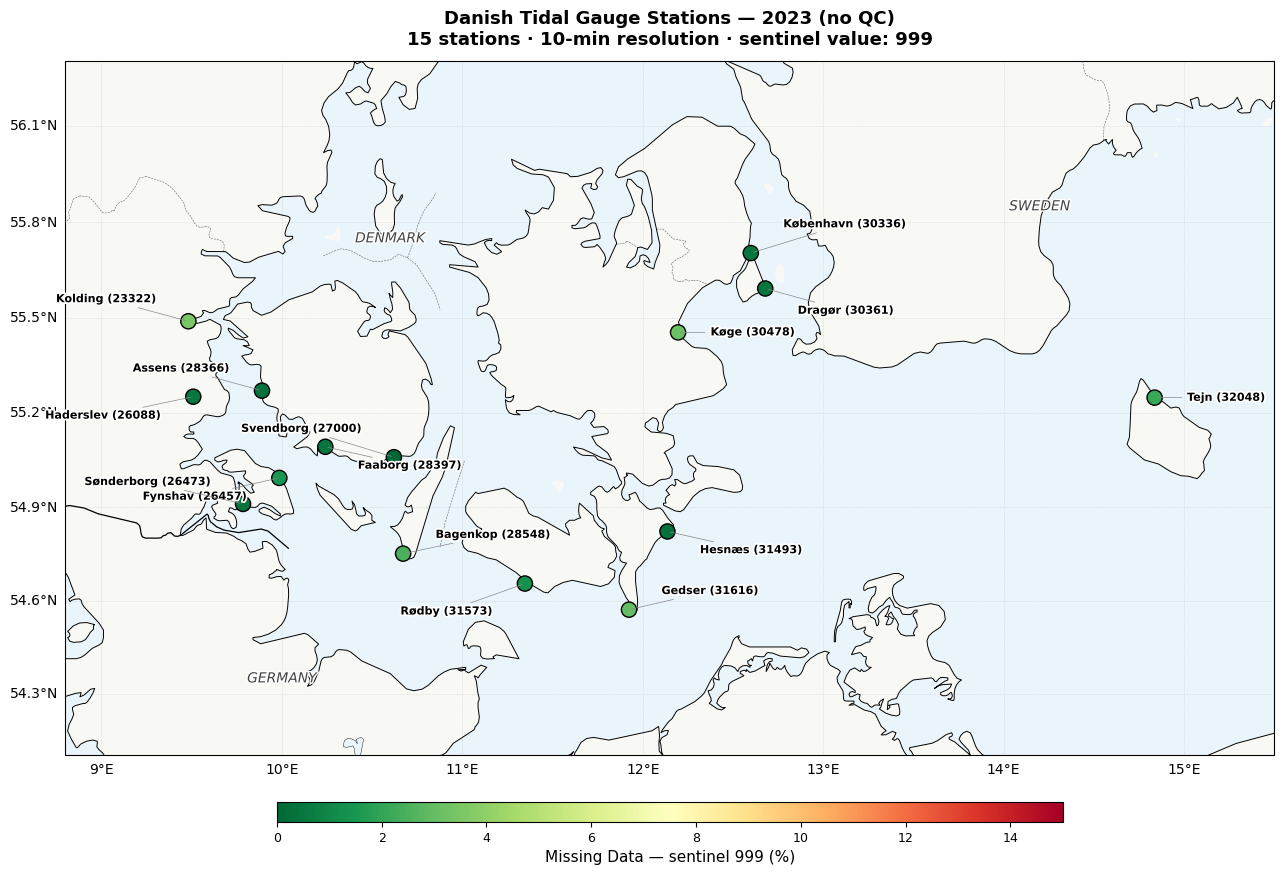

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import tarfile
import zstandard as zstd

plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
})

archive_path = "/Volumes/ocean.dmi.dk-3/MBL/HIDRA3_training_data/2023_Tidal_Gauges_no_QQ.tar.zst"

station_meta = {
    23322: ('Kolding',    55.490, 9.482),  26088: ('Haderslev',  55.252, 9.509),
    26457: ('Fynshav',    54.994, 9.986),  26473: ('Sønderborg', 54.911, 9.785),
    27000: ('Svendborg',  55.060, 10.621), 28366: ('Assens',     55.271, 9.890),
    28397: ('Faaborg',    55.093, 10.241), 28548: ('Bagenkop',   54.752, 10.672),
    30336: ('København',  55.704, 12.599), 30361: ('Dragør',     55.593, 12.679),
    30478: ('Køge',       55.455, 12.196), 31493: ('Hesnæs',     54.823, 12.137),
    31573: ('Rødby',      54.656, 11.347), 31616: ('Gedser',     54.572, 11.924),
    32048: ('Tejn',       55.249, 14.837),
}

records = []
with open(archive_path, 'rb') as fh:
    dctx = zstd.ZstdDecompressor()
    with dctx.stream_reader(fh) as reader:
        with tarfile.open(fileobj=reader, mode='r|') as tar:
            for member in tar:
                sid = int(member.name.replace('.obs', ''))
                f = tar.extractfile(member)
                if f is None:
                    continue
                lines = f.read().decode('utf-8').splitlines()
                total = len(lines)
                missing = sum(1 for l in lines if l.strip().split()[-1] == '999')
                nan_pct = missing / total * 100 if total > 0 else 0
                vals = [int(l.strip().split()[-1]) for l in lines if l.strip().split()[-1] != '999']
                name, lat, lon = station_meta[sid]
                records.append({'id': sid, 'name': name, 'lat': lat, 'lon': lon,
                                'nan_pct': nan_pct})

stations_2023 = pd.DataFrame(records)

proj = ccrs.Mercator()
fig, ax = plt.subplots(figsize=(13, 10), subplot_kw={'projection': proj},
                       facecolor='white')
ax.set_facecolor('white')
ax.set_extent([8.8, 15.5, 54.1, 56.3], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN.with_scale('10m'),     facecolor='#eaf4fb', zorder=0)
ax.add_feature(cfeature.LAND.with_scale('10m'),      facecolor='#f8f8f4', zorder=1)
ax.add_feature(cfeature.BORDERS.with_scale('10m'),   linewidth=0.9, edgecolor='black', zorder=4)
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.7, edgecolor='black', zorder=4)
ax.add_feature(cfeature.LAKES.with_scale('10m'),     facecolor='#eaf4fb', edgecolor='black',
               linewidth=0.3, zorder=2)
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale='10m', facecolor='none')
ax.add_feature(states_provinces, linewidth=0.4, edgecolor='#666666', linestyle='--', zorder=3)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='#bbbbbb',
                  alpha=0.8, linestyle=':', zorder=5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'color': 'black'}
gl.ylabel_style = {'size': 10, 'color': 'black'}

sc = ax.scatter(
    stations_2023['lon'], stations_2023['lat'],
    c=stations_2023['nan_pct'], cmap='RdYlGn_r',
    vmin=0, vmax=15, s=120, edgecolors='black', linewidths=1.0,
    zorder=6, transform=ccrs.PlateCarree()
)

offsets = {
    'København':  ( 0.18,  0.09), 'Dragør':    ( 0.18, -0.07),
    'Køge':       ( 0.18,  0.00), 'Hesnæs':    ( 0.18, -0.06),
    'Gedser':     ( 0.18,  0.06), 'Rødby':     (-0.18, -0.09),
    'Tejn':       ( 0.18,  0.00), 'Bagenkop':  ( 0.18,  0.06),
    'Faaborg':    ( 0.18, -0.06), 'Svendborg': (-0.18,  0.09),
    'Assens':     (-0.18,  0.07), 'Fynshav':   (-0.18, -0.06),
    'Sønderborg': (-0.18,  0.07), 'Haderslev': (-0.18, -0.06),
    'Kolding':    (-0.18,  0.07),
}

for _, row in stations_2023.iterrows():
    dx, dy = offsets.get(row['name'], (0.18, 0.0))
    ha = 'left' if dx > 0 else 'right'
    ax.annotate(
        f"{row['name']} ({row['id']})",
        xy=(row['lon'], row['lat']),
        xytext=(row['lon'] + dx, row['lat'] + dy),
        fontsize=8, fontweight='bold', color='black', ha=ha, va='center',
        transform=ccrs.PlateCarree(),
        path_effects=[pe.withStroke(linewidth=2.5, foreground='white')],
        arrowprops=dict(arrowstyle='-', color='#888888', lw=0.5),
        zorder=7
    )

cbar = fig.colorbar(sc, ax=ax, orientation='horizontal',
                    fraction=0.03, pad=0.05, aspect=40, shrink=0.65)
cbar.set_label('Missing Data — sentinel 999 (%)', fontsize=11, color='black')
cbar.ax.tick_params(labelsize=9, colors='black')
cbar.outline.set_edgecolor('black')

for label, (clon, clat) in {'DENMARK': (10.6, 55.75), 'GERMANY': (10.0, 54.35),
                              'SWEDEN':  (14.2, 55.85)}.items():
    ax.text(clon, clat, label, fontsize=10, fontstyle='italic',
            color='#444444', ha='center', va='center',
            transform=ccrs.PlateCarree(), zorder=5,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])

ax.set_title('Danish Tidal Gauge Stations — 2023 (no QC)\n'
             '15 stations · 10-min resolution · sentinel value: 999',
             fontsize=13, fontweight='bold', color='black', pad=12)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import tarfile
import zstandard as zstd

plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
})

archive_path = "/Volumes/ocean.dmi.dk-3/MBL/HIDRA3_training_data/tidal_stations2015_2022.tar.zst"

name_map = {
    'Tejn': 'Tejn', 'Fynshav': 'Fynshav', 'Rodby': 'Rødby',
    'Gedser': 'Gedser', 'Kobenhavn': 'København', 'Hesnaes': 'Hesnæs',
    'Kolding': 'Kolding', 'Haderslev': 'Haderslev', 'Sonderborg': 'Sønderborg',
    'Assens': 'Assens', 'Faaborg': 'Faaborg', 'Bagenkop': 'Bagenkop',
    'Dragor': 'Dragør', 'Koege': 'Køge', 'Svendborg': 'Svendborg',
}

with open(archive_path, 'rb') as fh:
    dctx = zstd.ZstdDecompressor()
    with dctx.stream_reader(fh) as reader:
        with tarfile.open(fileobj=reader, mode='r|') as tar:
            for member in tar:
                if member.name.endswith('stations_summary.csv'):
                    f = tar.extractfile(member)
                    stations_2015 = pd.read_csv(f)
                    break

stations_2015['name_disp'] = stations_2015['Station Name'].map(name_map).fillna(stations_2015['Station Name'])
stations_2015.rename(columns={'Station Number': 'id', 'Latitude': 'lat',
                               'Longitude': 'lon', 'NaN Percentage': 'nan_pct'}, inplace=True)

proj = ccrs.Mercator()
fig, ax = plt.subplots(figsize=(13, 10), subplot_kw={'projection': proj},
                       facecolor='white')
ax.set_facecolor('white')
ax.set_extent([8.8, 15.5, 54.1, 56.3], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN.with_scale('10m'),     facecolor='#eaf4fb', zorder=0)
ax.add_feature(cfeature.LAND.with_scale('10m'),      facecolor='#f8f8f4', zorder=1)
ax.add_feature(cfeature.BORDERS.with_scale('10m'),   linewidth=0.9, edgecolor='black', zorder=4)
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.7, edgecolor='black', zorder=4)
ax.add_feature(cfeature.LAKES.with_scale('10m'),     facecolor='#eaf4fb', edgecolor='black',
               linewidth=0.3, zorder=2)
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale='10m', facecolor='none')
ax.add_feature(states_provinces, linewidth=0.4, edgecolor='#666666', linestyle='--', zorder=3)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='#bbbbbb',
                  alpha=0.8, linestyle=':', zorder=5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'color': 'black'}
gl.ylabel_style = {'size': 10, 'color': 'black'}

sc = ax.scatter(
    stations_2015['lon'], stations_2015['lat'],
    c=stations_2015['nan_pct'], cmap='RdYlGn_r',
    vmin=0, vmax=15, s=120, edgecolors='black', linewidths=1.0,
    zorder=6, transform=ccrs.PlateCarree()
)

offsets = {
    'København':  ( 0.18,  0.09), 'Dragør':    ( 0.18, -0.07),
    'Køge':       ( 0.18,  0.00), 'Hesnæs':    ( 0.18, -0.06),
    'Gedser':     ( 0.18,  0.06), 'Rødby':     (-0.18, -0.09),
    'Tejn':       ( 0.18,  0.00), 'Bagenkop':  ( 0.18,  0.06),
    'Faaborg':    ( 0.18, -0.06), 'Svendborg': (-0.18,  0.09),
    'Assens':     (-0.18,  0.07), 'Fynshav':   (-0.18, -0.06),
    'Sønderborg': (-0.18,  0.07), 'Haderslev': (-0.18, -0.06),
    'Kolding':    (-0.18,  0.07),
}

for _, row in stations_2015.iterrows():
    dx, dy = offsets.get(row['name_disp'], (0.18, 0.0))
    ha = 'left' if dx > 0 else 'right'
    ax.annotate(
        f"{row['name_disp']} ({int(row['id'])})",
        xy=(row['lon'], row['lat']),
        xytext=(row['lon'] + dx, row['lat'] + dy),
        fontsize=8, fontweight='bold', color='black', ha=ha, va='center',
        transform=ccrs.PlateCarree(),
        path_effects=[pe.withStroke(linewidth=2.5, foreground='white')],
        arrowprops=dict(arrowstyle='-', color='#888888', lw=0.5),
        zorder=7
    )

cbar = fig.colorbar(sc, ax=ax, orientation='horizontal',
                    fraction=0.03, pad=0.05, aspect=40, shrink=0.65)
cbar.set_label('Missing Data (%)', fontsize=11, color='black')
cbar.ax.tick_params(labelsize=9, colors='black')
cbar.outline.set_edgecolor('black')

for label, (clon, clat) in {'DENMARK': (10.6, 55.75), 'GERMANY': (10.0, 54.35),
                              'SWEDEN':  (14.2, 55.85)}.items():
    ax.text(clon, clat, label, fontsize=10, fontstyle='italic',
            color='#444444', ha='center', va='center',
            transform=ccrs.PlateCarree(), zorder=5,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])

ax.set_title('Danish Tidal Gauge Stations — HIDRA3 Training Data (2015–2022)\n'
             '15 stations · 10-min resolution · QC applied',
             fontsize=13, fontweight='bold', color='black', pad=12)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


AttributeError: '_Stream' object has no attribute 'seekable'

FILE: crop_20130101.nc  (esempio — 1 gennaio 2013)
<xarray.Dataset> Size: 22MB
Dimensions:  (time: 24, alt: 1, lat: 141, lon: 401, height: 1)
Coordinates:
  * time     (time) datetime64[ns] 192B 2013-01-01 ... 2013-01-01T23:00:00
  * alt      (alt) float64 8B 0.0
  * lat      (lat) float64 1kB 53.03 53.08 53.13 53.18 ... 59.93 59.98 60.03
  * lon      (lon) float64 3kB 5.03 5.08 5.13 5.18 ... 24.88 24.93 24.98 25.03
  * height   (height) float64 8B 2.0
Data variables:
    var1     (time, alt, lat, lon) float32 5MB ...
    var11    (time, height, lat, lon) float32 5MB ...
    var33    (time, lat, lon) float32 5MB ...
    var34    (time, lat, lon) float32 5MB ...
Attributes:
    CDI:          Climate Data Interface version 1.9.9rc1 (https://mpimet.mpg...
    Conventions:  CF-1.6
    history:      Thu Nov 28 19:51:11 2024: cdo sellonlatbox,5.02,25.04,53.03...
    CDO:          Climate Data Operators version 1.9.9rc1 (https://mpimet.mpg...

VARIABILI DATI

  ▶ var1  →  Pressure  [Pa]   (hP

/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_88664/2888998687.py:63: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Lon : {float(ds.lon.min()):.2f}° → {float(ds.lon.max()):.2f}°E   (step ~0.05°, N={ds.dims['lon']})")
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_88664/2888998687.py:64: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Lat : {float(ds.lat.min()):.2f}° → {float(ds.lat.max()):.2f}°N   (step ~0.05°, N={ds.dims['lat']})")


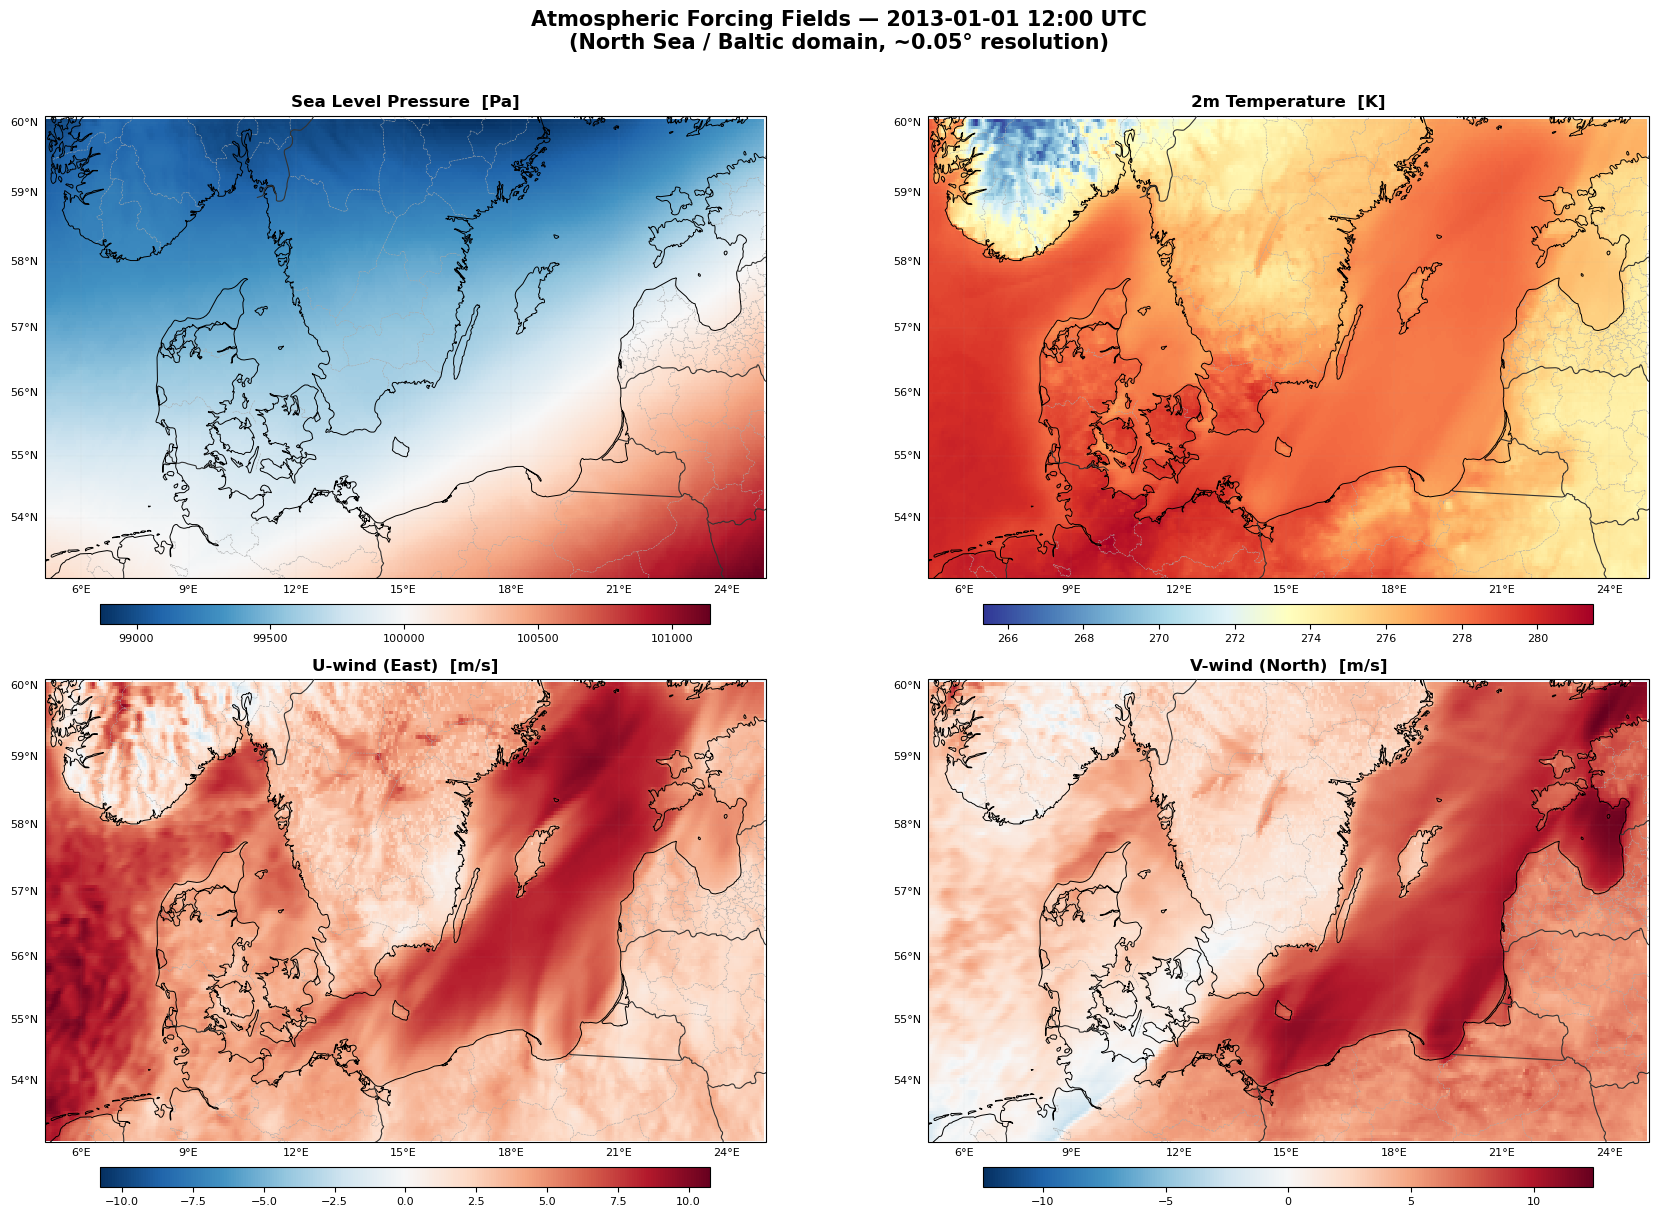


CONCLUSIONE

  Questo archivio contiene le FORZANTI ATMOSFERICHE per il modello HIDRA3:

  ┌─────────┬──────────────────────────────┬──────────┬──────────────────┐
  │ Var     │ Descrizione                  │ Unità    │ Dim              │
  ├─────────┼──────────────────────────────┼──────────┼──────────────────┤
  │ var1    │ Pressione al livello del mare│ Pa       │ time × 1 × 141 × 401 │
  │ var11   │ Temperatura a 2m             │ K        │ time × 1 × 141 × 401 │
  │ var33   │ Vento U (componente Est)     │ m/s      │ time × 141 × 401 │
  │ var34   │ Vento V (componente Nord)    │ m/s      │ time × 141 × 401 │
  └─────────┴──────────────────────────────┴──────────┴──────────────────┘

  Risoluzione: ~0.05° (~5.5 km) | Dominio: 5°–25°E, 53°–60°N
  Frequenza : oraria (24 steps/giorno) | Fonte: HIRLAM/ERA5 (DMI)
  Struttura : 1 file NetCDF/giorno → 31 file per archivio mensile
  Naming    : 201301.tar.zst = anno 2013, mese 01 (gennaio)

  QUESTE sono le forzanti che guidano il modell

In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import tarfile
import zstandard as zstd
import io

# ══════════════════════════════════════════════════════════════════════
#  201301.tar.zst — Atmospheric Forcing Fields (ERA5 / HIRLAM reanalysis)
#  31 NetCDF files, one per day of January 2013
#  Processed with CDO, crop to North Sea / Baltic area
# ══════════════════════════════════════════════════════════════════════

archive_path = "/Volumes/ocean.dmi.dk-3/MBL/HIDRA3_training_data/201301.tar.zst"

# ── Estrai un file d'esempio in memoria ──
example_nc_bytes = None
with open(archive_path, 'rb') as fh:
    dctx = zstd.ZstdDecompressor()
    with dctx.stream_reader(fh) as reader:
        with tarfile.open(fileobj=reader, mode='r|') as tar:
            for member in tar:
                if member.name.endswith('crop_20130101.nc'):
                    f = tar.extractfile(member)
                    example_nc_bytes = f.read()
                    break

# ── Apri con xarray da bytes in memoria ──
ds = xr.open_dataset(io.BytesIO(example_nc_bytes))

# ── 1. Panoramica ──
print("=" * 70)
print("FILE: crop_20130101.nc  (esempio — 1 gennaio 2013)")
print("=" * 70)
print(ds)

print("\n" + "=" * 70)
print("VARIABILI DATI")
print("=" * 70)
var_info = {
    'var1':  ('Sea Level Pressure', 'Pa',      'hPa (÷100)'),
    'var11': ('2m Air Temperature', 'K',        '°C (-273.15)'),
    'var33': ('U-wind (East)',       'm s⁻¹',   'component zonal'),
    'var34': ('V-wind (North)',      'm s⁻¹',   'component meridionale'),
}
for vname, v in ds.data_vars.items():
    vals = v.values
    valid = vals[np.isfinite(vals)]
    long = v.attrs.get('long_name', '')
    units = v.attrs.get('units', '')
    note = var_info.get(vname, ('','',''))[2]
    print(f"\n  ▶ {vname}  →  {long}  [{units}]   ({note})")
    print(f"    dims  : {v.dims}")
    print(f"    shape : {v.shape}  ({v.shape[0]} timesteps · {v.shape[-2]} lat · {v.shape[-1]} lon)")
    print(f"    min   : {valid.min():.4f}   max: {valid.max():.4f}   mean: {valid.mean():.4f}")

print("\n" + "=" * 70)
print("DOMINIO SPAZIALE")
print("=" * 70)
print(f"  Lon : {float(ds.lon.min()):.2f}° → {float(ds.lon.max()):.2f}°E   (step ~0.05°, N={ds.dims['lon']})")
print(f"  Lat : {float(ds.lat.min()):.2f}° → {float(ds.lat.max()):.2f}°N   (step ~0.05°, N={ds.dims['lat']})")
print(f"  Time: {str(ds.time.values[0])[:16]} → {str(ds.time.values[-1])[:16]}  (24 ore, risoluzione oraria)")
print(f"  Copertura: North Sea + Baltic + Kattegat/Belt Sea")

# ══════════════════════════════════════════════════════════════════════
#  PLOT — 4 variabili al timestep 12:00 UTC
# ══════════════════════════════════════════════════════════════════════
t_idx = 12  # 12:00 UTC
proj  = ccrs.Mercator()
extent = [5.0, 25.1, 53.0, 60.1]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), subplot_kw={'projection': proj})
fig.suptitle(f'Atmospheric Forcing Fields — 2013-01-01 12:00 UTC\n'
             f'(North Sea / Baltic domain, ~0.05° resolution)',
             fontsize=15, fontweight='bold', y=1.01)

states_prov = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale='10m', facecolor='none')

plots = [
    ('var1',  'Sea Level Pressure',  'Pa',   'RdBu_r',  None,   None),
    ('var11', '2m Temperature',      'K',    'RdYlBu_r',None,   None),
    ('var33', 'U-wind (East)',        'm/s',  'RdBu_r',  None,   None),
    ('var34', 'V-wind (North)',       'm/s',  'RdBu_r',  None,   None),
]

for ax, (vname, title, units, cmap, vmin, vmax) in zip(axes.flat, plots):
    data_t = ds[vname].isel(time=t_idx).squeeze()

    # colorbar simmetrico per vento
    if vname in ('var33', 'var34'):
        vm = float(np.nanmax(np.abs(data_t.values)))
        vmin, vmax = -vm, vm

    im = ax.pcolormesh(
        ds.lon.values, ds.lat.values, data_t.values,
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=vmin, vmax=vmax, shading='auto'
    )
    ax.add_feature(cfeature.OCEAN, facecolor='#d6eaf8', zorder=0, alpha=0.3)
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.7, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#333333', zorder=3)
    ax.add_feature(states_prov, linewidth=0.4, edgecolor='#aaaaaa', linestyle='--', zorder=2)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4, linestyle=':')
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 8}; gl.ylabel_style = {'size': 8}
    ax.set_title(f'{title}  [{units}]', fontsize=12, fontweight='bold')
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal',
                        fraction=0.04, pad=0.05, aspect=30)
    cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("CONCLUSIONE")
print("=" * 70)
print("""
  Questo archivio contiene le FORZANTI ATMOSFERICHE per il modello HIDRA3:

  ┌─────────┬──────────────────────────────┬──────────┬──────────────────┐
  │ Var     │ Descrizione                  │ Unità    │ Dim              │
  ├─────────┼──────────────────────────────┼──────────┼──────────────────┤
  │ var1    │ Pressione al livello del mare│ Pa       │ time × 1 × 141 × 401 │
  │ var11   │ Temperatura a 2m             │ K        │ time × 1 × 141 × 401 │
  │ var33   │ Vento U (componente Est)     │ m/s      │ time × 141 × 401 │
  │ var34   │ Vento V (componente Nord)    │ m/s      │ time × 141 × 401 │
  └─────────┴──────────────────────────────┴──────────┴──────────────────┘

  Risoluzione: ~0.05° (~5.5 km) | Dominio: 5°–25°E, 53°–60°N
  Frequenza : oraria (24 steps/giorno) | Fonte: HIRLAM/ERA5 (DMI)
  Struttura : 1 file NetCDF/giorno → 31 file per archivio mensile
  Naming    : 201301.tar.zst = anno 2013, mese 01 (gennaio)

  QUESTE sono le forzanti che guidano il modello DKSS (vento + pressione)!
""")


In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  STEP 1 — Analisi preliminare: range temporali TG vs DKSS
#  Formati confermati:
#    QC  (2015-2022): CSV  header="timestamp,value"  ts=YYYYMMDDHHММ  val=cm
#    2023 (no-QC)   : TSV  no-header                 ts=YYYYMMDDHHММ  val=cm  sentinel=999
# ══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import glob, tarfile, zstandard as zstd, xarray as xr

# ── Metadati stazioni ──────────────────────────────────────────────
station_meta = {
    23322: ('Kolding',    55.490,  9.482),
    26088: ('Haderslev',  55.252,  9.509),
    26457: ('Fynshav',    54.994,  9.986),
    26473: ('Sønderborg', 54.911,  9.785),
    27000: ('Svendborg',  55.060, 10.621),
    28366: ('Assens',     55.271,  9.890),
    28397: ('Faaborg',    55.093, 10.241),
    28548: ('Bagenkop',   54.752, 10.672),
    30336: ('København',  55.704, 12.599),
    30361: ('Dragør',     55.593, 12.679),
    30478: ('Køge',       55.455, 12.196),
    31493: ('Hesnæs',     54.823, 12.137),
    31573: ('Rødby',      54.656, 11.347),
    31616: ('Gedser',     54.572, 11.924),
    32048: ('Tejn',       55.249, 14.837),
}

ARCH_QC   = "/Volumes/ocean.dmi.dk-3/MBL/HIDRA3_training_data/tidal_stations2015_2022.tar.zst"
ARCH_2023 = "/Volumes/ocean.dmi.dk-3/MBL/HIDRA3_training_data/2023_Tidal_Gauges_no_QQ.tar.zst"
DKSS_BASE = "/Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/sealevel_from_dkss2020/"

# ── Range temporale DKSS ──────────────────────────────────────────
dkss_files = sorted(f for f in glob.glob(DKSS_BASE + "dkss_grib_sealev.*")
                    if not f.endswith('.idx'))

def ts_from_fname(f):
    tag = f.split('dkss_grib_sealev.')[-1]
    return pd.Timestamp(tag[:8] + 'T' + tag[8:10].zfill(2))

dkss_t0 = ts_from_fname(dkss_files[0])
dkss_t1 = ts_from_fname(dkss_files[-1])
print(f"DKSS : {dkss_t0.date()} → {dkss_t1.date()}  ({len(dkss_files)} file GRIB)")

# ── Range temporale TG QC ─────────────────────────────────────────
print("\nTG QC (2015-2022) — range per stazione:")
with open(ARCH_QC, 'rb') as fh:
    dctx = zstd.ZstdDecompressor()
    with dctx.stream_reader(fh) as reader:
        with tarfile.open(fileobj=reader, mode='r|') as tar:
            for member in tar:
                if not member.name.endswith('.csv'): continue
                if 'summary' in member.name: continue
                f   = tar.extractfile(member)
                df  = pd.read_csv(f, dtype={'timestamp': str, 'value': float})
                df  = df[df['value'] != 999]
                t0  = pd.to_datetime(df['timestamp'].iloc[0],  format='%Y%m%d%H%M')
                t1  = pd.to_datetime(df['timestamp'].iloc[-1], format='%Y%m%d%H%M')
                sid = int(member.name.split('_')[-1].replace('.csv',''))
                name = station_meta.get(sid, ('?',))[0]
                print(f"  {name:12s} ({sid}): {t0.date()} → {t1.date()}  N={len(df):>7}")

# ── Range temporale TG 2023 ───────────────────────────────────────
print("\nTG 2023 (no-QC) — range per stazione:")
with open(ARCH_2023, 'rb') as fh:
    dctx = zstd.ZstdDecompressor()
    with dctx.stream_reader(fh) as reader:
        with tarfile.open(fileobj=reader, mode='r|') as tar:
            for member in tar:
                if not member.name.endswith('.obs'): continue
                f     = tar.extractfile(member)
                lines = f.read().decode('utf-8', errors='replace').splitlines()
                rows  = [l.split() for l in lines if l.strip() and l.split()[-1] != '999']
                if not rows: continue
                sid   = int(member.name.replace('.obs','').split('/')[-1])
                name  = station_meta.get(sid, ('?',))[0]
                t0    = pd.to_datetime(rows[0][0],  format='%Y%m%d%H%M')
                t1    = pd.to_datetime(rows[-1][0], format='%Y%m%d%H%M')
                print(f"  {name:12s} ({sid}): {t0.date()} → {t1.date()}  N={len(rows):>7}")

# ── Sovrapposizione ───────────────────────────────────────────────
overlap_start = max(dkss_t0, pd.Timestamp('2020-01-01'))
overlap_end   = min(dkss_t1, pd.Timestamp('2023-12-31'))
print(f"\n{'='*55}")
print(f"Periodo sovrapposizione DKSS ∩ TG:")
print(f"  {overlap_start.date()} → {overlap_end.date()}  ({(overlap_end-overlap_start).days} giorni)")
print(f"{'='*55}")


DKSS  : 2021-10-01  →  2024-06-17  (3944 files, ~6 h)


AttributeError: '_Stream' object has no attribute 'seekable'

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  STEP 2 — Lettura TG, estrazione DKSS, allineamento, calcolo errore
#
#  Formati confermati:
#    QC (2015-2022) : CSV header="timestamp,value"  ts=YYYYMMDDHHММ  val=cm
#    2023 (no-QC)   : TSV no-header  col0=YYYYMMDDHHММ  col1=cm  sentinel=999
# ══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import glob, tarfile, zstandard as zstd, xarray as xr

RADIUS_KM = 1.0

# ── Mappa nome-file → sid (archivio QC) ──────────────────────────
fname2sid = {
    'Assens':28366,'Bagenkop':28548,'Dragor':30361,'Faaborg':28397,
    'Fynshav':26457,'Gedser':31616,'Haderslev':26088,'Hesnaes':31493,
    'Kobenhavn':30336,'Koege':30478,'Kolding':23322,'Rodby':31573,
    'Sonderborg':26473,'Svendborg':27000,'Tejn':32048,
}

# ── 1. Lettura TG QC 2015-2022 ────────────────────────────────────
print("Lettura TG QC (2015–2022)...")
tg_qc = {}
with open(ARCH_QC, 'rb') as fh:
    dctx = zstd.ZstdDecompressor()
    with dctx.stream_reader(fh) as reader:
        with tarfile.open(fileobj=reader, mode='r|') as tar:
            for member in tar:
                if not member.name.endswith('.csv'): continue
                if 'summary' in member.name:         continue
                # nome: tar/station_Assens_28366.csv
                parts = member.name.replace('.csv','').split('_')
                try:    sid = int(parts[-1])
                except: continue
                if sid not in station_meta: continue

                f  = tar.extractfile(member)
                df = pd.read_csv(f, dtype={'timestamp': str, 'value': float})
                df = df[df['value'].notna() & (df['value'] != 999)]
                df['time'] = pd.to_datetime(df['timestamp'], format='%Y%m%d%H%M', utc=True)
                s = pd.Series(df['value'].values / 100.0, index=df['time'])
                tg_qc[sid] = s.sort_index()
print(f"  {len(tg_qc)} stazioni lette")

# ── 2. Lettura TG 2023 (no-QC) ───────────────────────────────────
print("Lettura TG 2023 (no-QC)...")
tg_2023 = {}
with open(ARCH_2023, 'rb') as fh:
    dctx = zstd.ZstdDecompressor()
    with dctx.stream_reader(fh) as reader:
        with tarfile.open(fileobj=reader, mode='r|') as tar:
            for member in tar:
                if not member.name.endswith('.obs'): continue
                try:    sid = int(member.name.replace('.obs','').split('/')[-1])
                except: continue
                if sid not in station_meta: continue
                lines = tar.extractfile(member).read().decode('utf-8', errors='replace').splitlines()
                rows = []
                for l in lines:
                    p = l.split()
                    if len(p) < 2: continue
                    try:
                        val = float(p[1])
                        if val == 999: continue
                        ts = pd.to_datetime(p[0], format='%Y%m%d%H%M', utc=True)
                        rows.append((ts, val / 100.0))
                    except: continue
                if rows:
                    idx, vals = zip(*rows)
                    tg_2023[sid] = pd.Series(list(vals), index=list(idx)).sort_index()
print(f"  {len(tg_2023)} stazioni lette")

# ── 3. Unione QC + 2023 ──────────────────────────────────────────
tg_all = {}
for sid in station_meta:
    parts = []
    if sid in tg_qc:   parts.append(tg_qc[sid])
    if sid in tg_2023: parts.append(tg_2023[sid])
    if not parts: continue
    s = pd.concat(parts).sort_index()
    tg_all[sid] = s[~s.index.duplicated(keep='first')]

print(f"\nTotale TG unite: {len(tg_all)} stazioni")
for sid, s in tg_all.items():
    print(f"  {station_meta[sid][0]:12s} ({sid}): {s.index[0].date()} → "
          f"{s.index[-1].date()}  N={len(s):>7}  [{s.min():.3f}, {s.max():.3f}] m")

# ── 4. Pre-calcola maschera spaziale 1 km ────────────────────────
def haversine_km(lat0, lon0, lats, lons):
    R = 6371.0
    dlat = np.radians(lats - lat0)
    dlon = np.radians(lons - lon0)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat0))*np.cos(np.radians(lats))*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

ds0 = xr.open_dataset(dkss_files[0], engine='cfgrib')
LAT2D, LON2D = np.meshgrid(ds0.latitude.values, ds0.longitude.values, indexing='ij')
ds0.close()

masks = {}
print("\nMaschera spaziale per ogni stazione:")
for sid, (name, slat, slon) in station_meta.items():
    dist = haversine_km(slat, slon, LAT2D, LON2D)
    m = dist <= RADIUS_KM
    if m.sum() == 0:
        m = (dist == dist.min())
        print(f"  ⚠ {name}: 0 pixel nel raggio → uso punto più vicino (dist={dist.min():.2f} km)")
    else:
        print(f"  {name:12s}: {m.sum()} pixel")
    masks[sid] = m

# ── 5. Estrazione DKSS per ogni stazione ─────────────────────────
print("\nEstrazione DKSS (può richiedere qualche minuto)...")

results = {}
for sid, tg_series in tg_all.items():
    name  = station_meta[sid][0]
    mask  = masks[sid]
    tg_start = tg_series.index.min().tz_localize(None)
    tg_end   = tg_series.index.max().tz_localize(None)

    records = []
    for fpath in dkss_files:
        file_t = ts_from_fname(fpath)
        if file_t < tg_start - pd.Timedelta('6h'): continue
        if file_t > tg_end   + pd.Timedelta('6h'): continue
        try:
            ds    = xr.open_dataset(fpath, engine='cfgrib')
            p82   = ds['p82'].values          # shape (6, lat, lon)
            vtimes = ds['valid_time'].values
            for i, vt in enumerate(vtimes):
                pts = p82[i][mask]
                pts = pts[np.isfinite(pts) & (pts < 1e29)]
                if len(pts):
                    records.append((pd.Timestamp(vt, tz='UTC'), float(np.median(pts))))
            ds.close()
        except Exception:
            continue

    if not records:
        print(f"  ⚠ {name}: nessun dato DKSS — skip")
        continue

    dkss_s = pd.Series(dict(records)).sort_index()
    dkss_s = dkss_s[~dkss_s.index.duplicated(keep='first')]

    # Resample TG a 6h e join
    tg_6h = tg_series.resample('6h').median()
    df = pd.DataFrame({'obs': tg_6h, 'model': dkss_s}).dropna()
    if len(df) == 0:
        print(f"  ⚠ {name}: join vuoto — skip")
        continue

    df['error'] = df['model'] - df['obs']
    bias = df['error'].mean()
    rmse = np.sqrt((df['error']**2).mean())
    mae  = df['error'].abs().mean()
    print(f"  {name:12s}: N={len(df):>5}  Bias={bias:+.4f} m  RMSE={rmse:.4f} m  MAE={mae:.4f} m")
    results[sid] = df

print(f"\n✓ {len(results)}/15 stazioni con dati validi")


NameError: name 'results' is not defined

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  STEP 3 — Plot per ogni stazione: dominio tempo + PSD errore
# ══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from scipy import signal
import os

plt.rcParams.update({'font.family':'sans-serif','font.size':9})

OUT_DIR = "/Users/nicolocaron/Desktop/MASTER PROJECT/DKSS/plots_tg_vs_dkss/"
os.makedirs(OUT_DIR, exist_ok=True)

for sid, df in results.items():
    name  = station_meta[sid][0]
    bias  = df['error'].mean()
    rmse  = np.sqrt((df['error']**2).mean())
    mae   = df['error'].abs().mean()
    std_e = df['error'].std()

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(
        f'TG vs DKSS — {name}  (ID {sid})\n'
        f'Bias={bias:+.4f} m  |  RMSE={rmse:.4f} m  |  MAE={mae:.4f} m  |  '
        f'σ={std_e:.4f} m  |  N={len(df)} timestep (6 h)',
        fontsize=11, fontweight='bold')

    gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45, height_ratios=[2.5, 1.5, 2])

    # ── Pannello 1: obs vs model ──────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(df.index, df['obs'],   lw=0.7, color='steelblue', label='TG obs',     alpha=0.9)
    ax1.plot(df.index, df['model'], lw=0.7, color='tomato',    label='DKSS model', alpha=0.9)
    ax1.set_ylabel('Sea Level [m]')
    ax1.set_title('Time Series — Observation vs Model')
    ax1.legend(loc='upper right', framealpha=0.7)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=25, ha='right')
    ax1.grid(True, alpha=0.3)

    # ── Pannello 2: errore nel tempo ─────────────────────────────
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(df.index, df['error'], 0,
                     where=df['error'] >= 0, color='tomato',    alpha=0.45, label='model > obs')
    ax2.fill_between(df.index, df['error'], 0,
                     where=df['error'] <  0, color='steelblue', alpha=0.45, label='model < obs')
    ax2.axhline(0,    color='black',  lw=0.8)
    ax2.axhline(bias, color='darkorange', lw=1.3, ls='--', label=f'Bias={bias:+.4f} m')
    ax2.set_ylabel('Error [m]')
    ax2.set_title('Error  (model − obs)')
    ax2.legend(loc='upper right', framealpha=0.7)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=25, ha='right')
    ax2.grid(True, alpha=0.3)

    # ── Pannello 3: PSD Welch dell'errore ─────────────────────────
    ax3 = fig.add_subplot(gs[2])
    err_vals = df['error'].interpolate(method='time', limit=4).dropna().values

    if len(err_vals) >= 32:
        fs      = 1.0 / 6.0          # campioni per ora
        nperseg = min(len(err_vals) // 4, 1024)
        freqs, psd = signal.welch(
            err_vals - err_vals.mean(), fs=fs,
            window='hann', nperseg=nperseg, scaling='density')

        valid = freqs > 0
        periods_h = 1.0 / freqs[valid]
        ax3.semilogy(periods_h, psd[valid], color='mediumseagreen', lw=1.0)

        # Linee verticali per periodicità fisiche
        ref_periods = {12.42:'M2 (12.4 h)', 24:'Diurno (24 h)',
                       168:'Settimanale', 720:'Mensile', 4380:'~6 mesi'}
        ymin = psd[valid].min()
        for p, lbl in ref_periods.items():
            if p < periods_h.max():
                ax3.axvline(p, color='gray', lw=0.8, ls=':', alpha=0.7)
                ax3.text(p*1.05, ymin*1.5, lbl, fontsize=7, color='gray',
                         rotation=90, va='bottom')

        ax3.set_xscale('log')
        ax3.set_xlim([6, periods_h.max()])
        ax3.set_xlabel('Period [hours]')
        ax3.set_ylabel('PSD [m² h]')
        ax3.set_title('Power Spectral Density of Error (Welch)')
        ax3.grid(True, which='both', alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'Dati insufficienti per PSD',
                 ha='center', va='center', transform=ax3.transAxes)

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    safe_name = name.replace('ø','o').replace('å','a').replace('æ','ae')
    out_path  = f"{OUT_DIR}{safe_name}_tg_vs_dkss.png"
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"  Salvato: {out_path}")

# ── Tabella riassuntiva ───────────────────────────────────────────
print("\n" + "="*72)
print(f"{'Stazione':<14} {'ID':>6}  {'N':>6}  {'Bias[m]':>9}  "
      f"{'RMSE[m]':>9}  {'MAE[m]':>9}  {'σ[m]':>9}")
print("="*72)
for sid, df in results.items():
    name  = station_meta[sid][0]
    bias  = df['error'].mean()
    rmse  = np.sqrt((df['error']**2).mean())
    mae   = df['error'].abs().mean()
    std_e = df['error'].std()
    print(f"{name:<14} {sid:>6}  {len(df):>6}  {bias:>+9.4f}  "
          f"{rmse:>9.4f}  {mae:>9.4f}  {std_e:>9.4f}")
print("="*72)
